# Body Measurement Regression from Images

This notebook trains a CNN regressor that predicts **8 anthropometric
measurements** (in centimetres) from a single body image.

Pipeline overview:

1. **Labels** are loaded from two CSV files (one per gender) into the
   `male_data` / `female_data` DataFrames.
2. **Images** are streamed from two **TFRecord** files (`tfrecord_male`,
   `tfrecord_female`). Each TFRecord stores the images **in the same row order
   as its label DataFrame**, so record *i* corresponds to label row *i*.
3. The data pipeline **pairs each image with its label**, splits the data into
   train / validation / test, standardises the labels, and feeds batched
   `(image, measurements)` tuples to Keras.
4. A frozen ImageNet backbone (ResNet50 by default) with a small regression
   head is trained, then optionally fine-tuned end to end.
5. The model is evaluated separately on the male, female and combined test sets,
   reporting the error back in real centimetres.

## 1. Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.layers import (
    Input, GlobalAveragePooling2D,GlobalMaxPooling2D,Concatenate, Dense, Dropout, BatchNormalization, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

# Reproducibility: fix every relevant RNG.
SEED = 34
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Let TensorFlow grow GPU memory on demand instead of pre-allocating all of it.
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as exc:  # already initialised
        print(exc)

AUTOTUNE = tf.data.AUTOTUNE

# Mount Google Drive (only needed on Colab).
try:
    import google.colab  # noqa: F401
    google.colab.drive.mount("/content/drive")
except ImportError:
    print("Not running on Colab - skipping Drive mount.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ImageNet backbones used as feature extractors and their matching
# preprocessing functions.
from tensorflow.keras.applications import (
    ResNet50,
    resnet50
)

## 2. Configuration

In [ ]:
# --- Paths -----------------------------------------------------------------
path = "/"
save_path = "/"

# TFRecord files holding the images (one per gender), written in the SAME order
# as the corresponding label DataFrame. Adjust the file names to match yours.
tfrecord_male = path + "/Used/male.tfrecord"
tfrecord_female = path + "/Used/female.tfrecord"

# CSV with all the annotations

column_names = [
    "chest_circ", "waist_circ", "pelvis_circ", "neck_circ", "bicep_circ", "thigh_circ",
    "knee_circ", "arm_length", "leg_length", "calf_length", "head_circ", "wrist_circ",
    "arm_span", "shoulders_width", "torso_length", "inner_leg",
] # All columns present in the raw annotation files, in order.

male_data = pd.read_csv(path + "/Used/bodymeasurements_m_augmented.csv", names=column_names)
female_data = pd.read_csv(path + "/Used/bodymeasurements_f_augmented.csv", names=column_names)

# --- Data split ------------------------------------------------------------
train_size = 0.70
val_size = 0.15
# test_size is implicit: 1 - train_size - val_size

# --- Image / training hyper-parameters -------------------------------------
IMG_SIZE = 224          # network input size

batch_size = 64
N_OUTPUTS = 8           # number of measurements predicted

EPOCHS = 150            # max epochs for the frozen-backbone stage
INIT_LR = 1e-4

# Optional second stage: unfreeze the backbone and fine-tune end to end.
FINE_TUNE = True
FINE_TUNE_EPOCHS = 50
FINE_TUNE_LR = 1e-5

SHUFFLE_BUFFER = 8192

## 3. Labels

In [ ]:



# Build an image-ID column matching the on-disk file names, e.g. "men/000000.png".
# The row order here MUST match the record order inside the TFRecord files.
male_data.insert(0, "ID", [f"men/{i:06d}.png" for i in range(len(male_data))])
female_data.insert(0, "ID", [f"women/{i:06d}.png" for i in range(len(female_data))])

# Keep only the 8 measurements we want to predict (plus the ID).
cols_keep = [
    "ID",
    "waist_circ", "pelvis_circ", "arm_span",
    "chest_circ", "arm_length", "shoulders_width", "torso_length","leg_length"
]
male_data = male_data[cols_keep].copy()
female_data = female_data[cols_keep].copy()

print(f"Male samples:   {len(male_data)}")
print(f"Female samples: {len(female_data)}")
male_data.head(3)

Male samples:   75000
Female samples: 75000


,ID,waist_circ,pelvis_circ,arm_span,chest_circ,arm_length,shoulders_width,torso_length,leg_length
0,men/000000.png,73.213088,92.503097,182.0555,83.576515,55.186850,34.255001,49.249297,84.096402
1,men/000001.png,88.686590,100.846918,171.1829,101.702204,49.606380,36.272103,51.644093,73.995692
2,men/000002.png,97.596672,100.898346,170.2976,104.289594,47.996426,37.544197,50.525796,71.371871


In [ ]:
# Each backbone expects its inputs preprocessed in a specific way (mean
# subtraction, scaling, channel order, ...). Map backbone name -> function.
preprocess_input = {"ResNet50": resnet50.preprocess_input}

## 4. Data pipeline (TFRecord images + DataFrame labels)

The key idea is that **images and labels live in two separate sources** that
must be joined positionally:

* `tfrecord_male` / `tfrecord_female` yield images **in file order**.
* `male_data` / `female_data` hold the labels **in the same order**.

We therefore `zip` the image dataset with a label dataset built from the
DataFrame, attaching a per-row *split id* (train / val / test) computed
deterministically in NumPy. Filtering on that split id keeps every image
glued to its own label, so the train/val/test sets stay perfectly aligned.

Notes:
* The split is filtered **before** the JPEG is decoded, so discarded samples
  cost almost nothing.
* Label standardisation statistics (`mean`, `std`) are computed on the
  **training labels only**, avoiding information leakage. They are returned so
  predictions can later be converted back to centimetres.

In [ ]:
TRAIN, VAL, TEST = 0, 1, 2


def parse_tfrecord(example_proto):
    """Parse one serialized Example and return the still-encoded image bytes.

    Decoding is deferred to `decode_and_preprocess` so that samples filtered out
    by the split never pay the JPEG-decode cost.
    """
    feature_description = {"image": tf.io.FixedLenFeature([], tf.string)}
    example = tf.io.parse_single_example(example_proto, feature_description)
    return example["image"]


def decode_and_preprocess(encoded_image, label, preprocess_model):
    """Decode the image, take a centred square crop, resize and preprocess it.

    The label is passed through unchanged so the dataset keeps yielding
    `(image, measurements)` tuples.
    """
    image = tf.io.decode_jpeg(encoded_image, channels=3)

    shape = tf.shape(image)
    height, width = shape[0], shape[1]

    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = preprocess_input[preprocess_model](image)
    return image, label


def assign_splits(n, train_size, val_size, seed=SEED):
    """Return an int array of length `n` with 0=train, 1=val, 2=test, shuffled."""
    rng = np.random.default_rng(seed)
    perm = rng.permutation(n)
    n_train = int(n * train_size)
    n_val = int(n * val_size)
    splits = np.empty(n, dtype=np.int32)
    splits[perm[:n_train]] = TRAIN
    splits[perm[n_train:n_train + n_val]] = VAL
    splits[perm[n_train + n_val:]] = TEST
    return splits


def create_datasets(
    male_tfrecord,
    female_tfrecord,
    male_data,
    female_data,
    batch_size,
    train_size,
    val_size,
    preprocess_model,
    shuffle_buffer=SHUFFLE_BUFFER,
    seed=SEED,
):
    """Build the train / val / test `tf.data` datasets from TFRecords + labels.

    Returns
    -------
    train_ds, val_ds, male_test_ds, female_test_ds, total_test_ds : tf.data.Dataset
        Datasets yielding `(image, standardised_measurements)` batches.
    mean, std : pd.Series
        Per-measurement statistics (in cm) used to standardise the labels;
        needed to map predictions back to real units.
    """
    feature_cols = [c for c in male_data.columns if c != "ID"]

    # Deterministic split assignment, per gender, kept in NumPy.
    male_splits = assign_splits(len(male_data), train_size, val_size, seed)
    female_splits = assign_splits(len(female_data), train_size, val_size, seed)

    # Standardisation stats from the TRAIN labels of BOTH genders (no leakage).
    train_male = male_data.loc[male_splits == TRAIN, feature_cols].to_numpy(np.float32)
    train_female = female_data.loc[female_splits == TRAIN, feature_cols].to_numpy(np.float32)
    train_labels = np.concatenate([train_male, train_female], axis=0)

    # Commented the following to test if standarization is ok or results are worse
    mean = pd.Series(train_labels.mean(axis=0), index=feature_cols)
    std = pd.Series(train_labels.std(axis=0), index=feature_cols).replace(0, 1)
    mean_np = mean.to_numpy(np.float32)
    std_np = std.to_numpy(np.float32)


    def build_gender_ds(tfrecord_path, data_df, splits):
        """Zip TFRecord images with their standardised labels and split ids."""
        labels = data_df[feature_cols].to_numpy(np.float32)
        labels = (labels - mean_np) / std_np

        image_ds = tf.data.TFRecordDataset(tfrecord_path)
        image_ds = image_ds.map(parse_tfrecord, num_parallel_calls=AUTOTUNE)
        label_ds = tf.data.Dataset.from_tensor_slices(
            (labels, splits.astype(np.int32))
        )
        # element -> (encoded_image, (label_vector, split_id))
        return tf.data.Dataset.zip((image_ds, label_ds))

    male_ds = build_gender_ds(male_tfrecord, male_data, male_splits)
    female_ds = build_gender_ds(female_tfrecord, female_data, female_splits)

    def take_split(ds, split_id):
        """Keep only one split and drop the split id, yielding (image, label)."""
        ds = ds.filter(lambda img, ls: tf.equal(ls[1], split_id))
        return ds.map(lambda img, ls: (img, ls[0]), num_parallel_calls=AUTOTUNE)

    def finalize(ds, training=False):
        """Decode/preprocess images, optionally shuffle, batch and prefetch."""
        ds = ds.map(
            lambda img, lab: decode_and_preprocess(img, lab, preprocess_model),
            num_parallel_calls=AUTOTUNE,
        )
        if training:
            ds = ds.shuffle(shuffle_buffer, seed=seed)
        return ds.batch(batch_size).prefetch(AUTOTUNE)

    # Combine genders. Training interleaves them so each batch mixes both.
    male_train = take_split(male_ds, TRAIN)
    female_train = take_split(female_ds, TRAIN)
    train_ds = tf.data.Dataset.sample_from_datasets(
        [male_train, female_train], weights=[0.5, 0.5],
        seed=seed, stop_on_empty_dataset=False,
    )
    val_ds = take_split(male_ds, VAL).concatenate(take_split(female_ds, VAL))

    train_ds = finalize(train_ds, training=True)
    val_ds = finalize(val_ds)
    male_test_ds = finalize(take_split(male_ds, TEST))
    female_test_ds = finalize(take_split(female_ds, TEST))
    total_test_ds = male_test_ds.concatenate(female_test_ds)

    return train_ds, val_ds, male_test_ds, female_test_ds, total_test_ds, mean, std

## 5. Model

In [ ]:
# Backbones to evaluate. Uncomment to add more.
encoder_names = [ResNet50]

In [ ]:
def get_model(encoder_fn, n_outputs=N_OUTPUTS, l2_reg=1e-5, dropout=0.3):
    """Build a regression model: frozen ImageNet backbone + dense head.

    Returns both the full `model` and the `backbone`, so the backbone can be
    unfrozen later for fine-tuning.
    """
    backbone = encoder_fn(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    backbone.trainable = False  # start with a frozen feature extractor

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=False)

    # MEJORA: Concatenar Average y Max Pooling para capturar más contexto
    x_avg = GlobalAveragePooling2D()(x)
    x_max = GlobalMaxPooling2D()(x)
    x = Concatenate()([x_avg, x_max])

    # MEJORA: Bucle actualizado con Dropout y Swish
    for units in (512, 256, 128):
        x = Dense(units, use_bias=False,
                  kernel_regularizer=regularizers.l2(l2_reg))(x)
        x = BatchNormalization()(x)
        x = Activation("swish")(x) # Swish suele ser mejor que ReLU en regresiones
        x = Dropout(dropout)(x)    # El dropout que faltaba

    outputs = Dense(n_outputs, name="measurements")(x)

    model = Model(inputs, outputs, name=f"{encoder_fn.__name__}_regressor")
    return model, backbone

In [ ]:
# Fine-tuning
def unfreeze_partial_backbone(backbone, encoder_name):
    """
    Unfreezes only the last convolutional block of the backbone,
    ensuring BatchNormalization layers remain completely frozen.
    """
    # 1. Start by unfreezing everything in the backbone
    backbone.trainable = True

    # 2. Determine the prefix of the last block based on the architecture
    target_block = "conv5_block"

    # 3. Iterate through all layers and selectively freeze
    for layer in backbone.layers:
        # Freeze layers that do NOT belong to the target block (if recognized)
        if target_block and not layer.name.startswith(target_block):
            layer.trainable = False

        # CRITICAL SAFETY: ALWAYS keep BatchNormalization layers frozen
        if isinstance(layer, BatchNormalization):
            layer.trainable = False

# Evalutation

In [ ]:
def plot_learning_curves(history, encoder_name, stage="Stage 1"):
    """Plots Loss and MAE per epoch for training and validation."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss Plot (Huber)
    ax1.plot(history.history['loss'], label='Train Loss', color='royalblue', lw=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='darkorange', lw=2)
    ax1.set_title(f'[{encoder_name}] {stage} - Huber Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # MAE Plot
    ax2.plot(history.history['mean_absolute_error'], label='Train MAE', color='seagreen', lw=2)
    ax2.plot(history.history['val_mean_absolute_error'], label='Val MAE', color='crimson', lw=2)
    ax2.set_title(f'[{encoder_name}] {stage} - MAE (cm)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MAE')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [ ]:
def predict_measurements_and_evaluate(dataset, model, mean, std, dataset_name="Test Set", plot_diagnostics=False):
    """Evaluates the model and optionally generates Scatter, Bland-Altman, and Boxplot charts."""
    y_trues, y_preds = [], []

    for batch_x, batch_y in dataset:
        y_preds.append(model.predict(batch_x, verbose=0))
        y_trues.append(batch_y.numpy())

    y_preds = np.vstack(y_preds)
    y_trues = np.vstack(y_trues)

    # De-standardize back to real centimeters
    if isinstance(mean, (int, float)):
        mean_vals, std_vals = mean, std
        col_names = [f"var_{i}" for i in range(y_preds.shape[1])]
    else:
        mean_vals, std_vals = mean.to_numpy(), std.to_numpy()
        col_names = list(mean.index)

    y_preds_real = y_preds * std_vals + mean_vals
    y_trues_real = y_trues * std_vals + mean_vals

    # Calculate Absolute Error
    abs_err = np.abs(y_preds_real - y_trues_real)
    per_col_mae = abs_err.mean(axis=0)

    # Print results per column
    for name, mae_val in zip(col_names, per_col_mae):
        print(f"{name:>16}:  MAE = {mae_val:5.2f} cm")

    # Calculate and print overall average
    mean_mae = per_col_mae.mean()
    print(f"\n{'Mean MAE':>16}: {mean_mae:5.2f} cm")

    # ====================================================================
    # DIAGNOSTIC PLOTS GENERATION
    # ====================================================================
    if plot_diagnostics:
        n_vars = len(col_names)
        cols = 4
        rows = int(np.ceil(n_vars / cols))

        # ---------------------------------------------------------
        # 1. SCATTER PLOT (True vs. Predicted)
        # ---------------------------------------------------------
        fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.5 * rows))
        axes = axes.flatten()

        for i in range(n_vars):
            ax = axes[i]
            y_t, y_p = y_trues_real[:, i], y_preds_real[:, i]

            ax.scatter(y_t, y_p, alpha=0.3, color='royalblue', edgecolors='none', s=15)

            # Identity line y=x
            min_v, max_v = min(np.min(y_t), np.min(y_p)), max(np.max(y_t), np.max(y_p))
            ax.plot([min_v, max_v], [min_v, max_v], 'r--', lw=1.5, label='y=x')

            ax.set_title(col_names[i], fontsize=11, fontweight='bold')
            ax.set_xlabel('True Value (cm)', fontsize=9)
            ax.set_ylabel('Predicted Value (cm)', fontsize=9)
            ax.grid(True, linestyle='--', alpha=0.5)

        for j in range(n_vars, len(axes)): axes[j].axis('off') # Hide empty subplots
        plt.suptitle(f'Scatter Plot (True vs Predicted) — {dataset_name}', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

        # ---------------------------------------------------------
        # 2. BLAND-ALTMAN PLOT
        # ---------------------------------------------------------
        fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.5 * rows))
        axes = axes.flatten()

        for i in range(n_vars):
            ax = axes[i]
            y_t, y_p = y_trues_real[:, i], y_preds_real[:, i]

            diff = y_p - y_t
            mean_base = (y_p + y_t) / 2.0
            md, sd = np.mean(diff), np.std(diff)

            ax.scatter(mean_base, diff, alpha=0.3, color='seagreen', edgecolors='none', s=15)
            ax.axhline(md, color='black', linestyle='-', lw=1.5, label=f'Bias: {md:.1f}')
            ax.axhline(md + 1.96*sd, color='crimson', linestyle='--', alpha=0.7, label='±1.96 SD')
            ax.axhline(md - 1.96*sd, color='crimson', linestyle='--', alpha=0.7)

            ax.set_title(col_names[i], fontsize=11, fontweight='bold')
            ax.set_xlabel('Average [(Pred+True)/2]', fontsize=9)
            ax.set_ylabel('Difference (Pred-True)', fontsize=9)
            ax.grid(True, linestyle='--', alpha=0.5)

        for j in range(n_vars, len(axes)): axes[j].axis('off')
        plt.suptitle(f'Bland-Altman Analysis — {dataset_name}', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

        # ---------------------------------------------------------
        # 3. GLOBAL ABSOLUTE ERROR BOXPLOT (NEW)
        # ---------------------------------------------------------
        plt.figure(figsize=(10, 6))

        # Create a list of absolute error arrays for each variable
        box_data = [abs_err[:, i] for i in range(n_vars)]

        # Create the boxplot
        bp = plt.boxplot(box_data, patch_artist=True, labels=col_names,
                         medianprops={'color': 'crimson', 'linewidth': 2},
                         flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'markersize': 3, 'alpha': 0.3})

        # Style the boxes
        for box in bp['boxes']:
            box.set_facecolor('lightblue')
            box.set_alpha(0.7)

        plt.title(f'Global Absolute Error Distribution — {dataset_name}', fontsize=14, fontweight='bold')
        plt.ylabel('Absolute Error (cm)', fontsize=11)
        plt.xlabel('Measurement', fontsize=11)
        plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
        plt.grid(True, axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    return mean_mae

### Quick check: visualise a few TFRecord samples

In [ ]:
import matplotlib.pyplot as plt


def show_tfrecord_samples(tfrecord_path, n=3):
    """Decode and display the first `n` images stored in a TFRecord file."""
    ds = tf.data.TFRecordDataset(tfrecord_path).map(parse_tfrecord).take(n)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    axes = np.atleast_1d(axes)
    for ax, encoded in zip(axes, ds):
        image = tf.io.decode_jpeg(encoded, channels=3).numpy()
        ax.imshow(image)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# show_tfrecord_samples(tfrecord_male, n=3)

## 6. Training

For each backbone we:

1. Build the datasets (images paired with their labels).
2. Train the dense head with the backbone frozen.
3. (Optional) Unfreeze the backbone and fine-tune end to end at a lower LR.
4. Evaluate on the male, female and combined test sets and record the results.

Backbone: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

Stage 1: Training the dense head (Frozen Backbone)...
Epoch 1/150
   1641/Unknown 173s 85ms/step - loss: 0.2542 - mean_absolute_error: 0.5513

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1641/1641 ━━━━━━━━━━━━━━━━━━━━ 209s 107ms/step - loss: 0.1768 - mean_absolute_error: 0.4452 - val_loss: 0.0577 - val_mean_absolute_error: 0.2321 - learning_rate: 1.0000e-04
Epoch 2/150
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 156s 93ms/step - loss: 0.0936 - mean_absolute_error: 0.3142 - val_loss: 0.0509 - val_mean_absolute_error: 0.2175 - learning_rate: 1.0000e-04
Epoch 3/150
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 157s 94ms/step - loss: 0.0775 - mean_absolute_error: 0.2838 - val_loss: 0.0453 - val_mean_absolute_error: 0.2059 - learning_rate: 1.0000e-04
Epoch 4/150
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 157s 94ms/step - loss: 0.0683 - mean_absolute_error: 0.2657 - val_loss: 0.0423 - val_mean_absolute_error: 0.1988 - learning_rate: 1.0000e-04
Epoch 5/150
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 157s 94ms/step - loss: 0.0636 - mean_absolute_error: 0.2567 - val_loss: 0.0389 - val_mean_absolute_error: 0.1893 - learning_rate: 1.0000e-04
Epoch 6/150
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 156s 93ms/step - loss: 0.0601 - mean_absolute_er

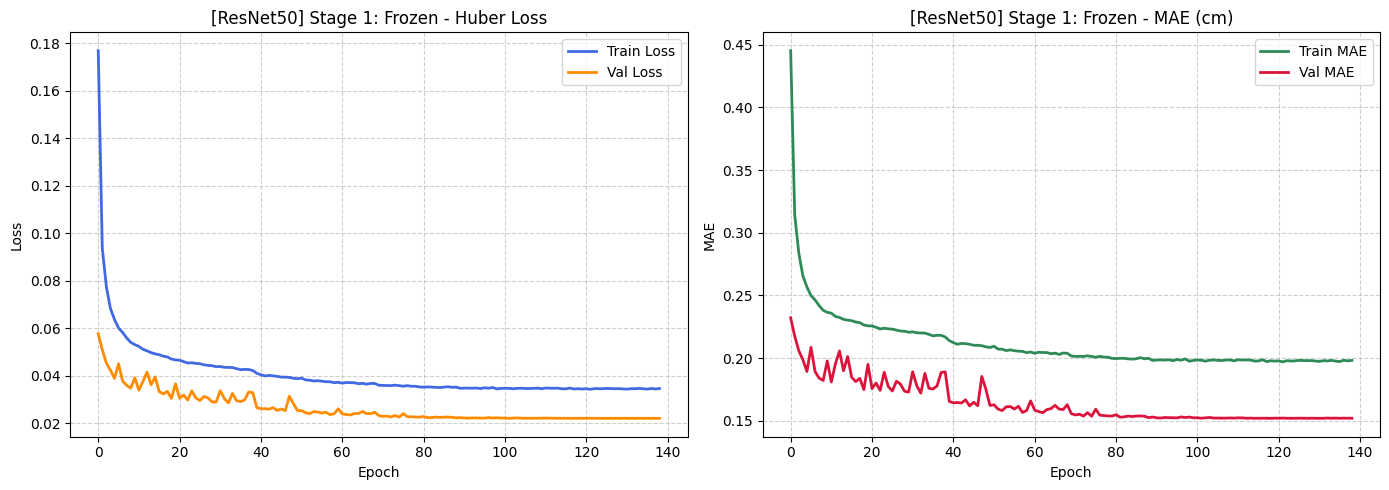


Stage 2: Partial fine-tuning of the backbone...
Epoch 1/50
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 228s 125ms/step - loss: 0.0365 - mean_absolute_error: 0.2034 - val_loss: 0.0213 - val_mean_absolute_error: 0.1487 - learning_rate: 1.0000e-05
Epoch 2/50
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 192s 115ms/step - loss: 0.0348 - mean_absolute_error: 0.1984 - val_loss: 0.0200 - val_mean_absolute_error: 0.1435 - learning_rate: 1.0000e-05
Epoch 3/50
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 191s 115ms/step - loss: 0.0345 - mean_absolute_error: 0.1977 - val_loss: 0.0192 - val_mean_absolute_error: 0.1403 - learning_rate: 1.0000e-05
Epoch 4/50
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 191s 115ms/step - loss: 0.0335 - mean_absolute_error: 0.1945 - val_loss: 0.0193 - val_mean_absolute_error: 0.1404 - learning_rate: 1.0000e-05
Epoch 5/50
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 192s 115ms/step - loss: 0.0330 - mean_absolute_error: 0.1927 - val_loss: 0.0182 - val_mean_absolute_error: 0.1364 - learning_rate: 1.0000e-05
Epoch 6/50
1641/1641 ━━━━━━━━━━

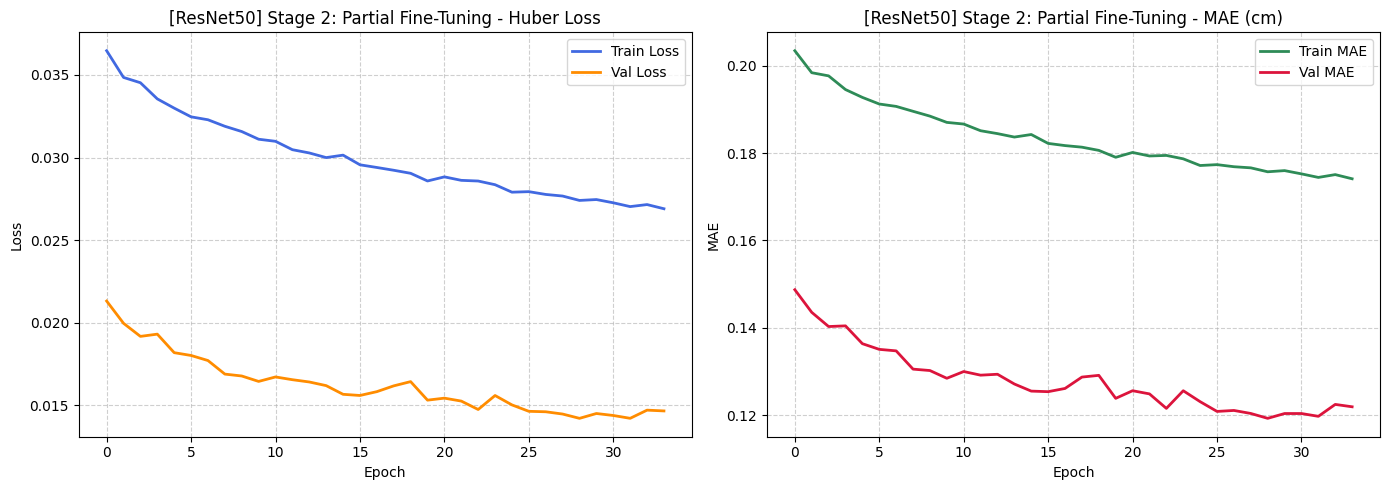

In [ ]:
results_df = pd.DataFrame(columns=["mean_mae", "mean_mse"])

for encoder in encoder_names:
    encoder_name = encoder.__name__
    print("=" * 60)
    print(f"Backbone: {encoder_name}")
    print("=" * 60)

    (train_gen, val_gen, test_gen_male, test_gen_female,
     test_gen_total, mean, std) = create_datasets(
        tfrecord_male, tfrecord_female, male_data, female_data,
        batch_size, train_size, val_size, encoder_name,
    )

    model, backbone = get_model(encoder)

    # Standard EarlyStopping for Stage 1 (Head training)
    early_stopping_stage1 = EarlyStopping(
        monitor="val_loss", patience=20, min_delta=0.001,
        restore_best_weights=True, verbose=1,
    )
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=6, min_lr=1e-7, verbose=1,
    )

    callbacks_stage1 = [early_stopping_stage1, reduce_lr]

    # --- Stage 1: train the head with a frozen backbone ---------------------
    print("\nStage 1: Training the dense head (Frozen Backbone)...")
    model.compile(
        optimizer=Adam(learning_rate=INIT_LR),
        loss=Huber(delta=1.0),
        metrics=["mean_absolute_error"],
    )
    history_stage1 = model.fit(
        train_gen, epochs=EPOCHS,
        validation_data=val_gen, callbacks=callbacks_stage1,
    )
    plot_learning_curves(history_stage1, encoder_name, stage="Stage 1: Frozen")

    # --- Stage 2: optional partial fine-tuning ------------------------------
    if FINE_TUNE:
        print("\nStage 2: Partial fine-tuning of the backbone...")

        # Apply our custom partial unfreeze function
        unfreeze_partial_backbone(backbone, encoder_name)

        # Strict EarlyStopping for fine-tuning to prevent catastrophic forgetting
        early_stopping_ft = EarlyStopping(
            monitor="val_loss", patience=5, min_delta=0.001,
            restore_best_weights=True, verbose=1,
        )
        callbacks_stage2 = [early_stopping_ft, reduce_lr]

        model.compile(
            optimizer=Adam(learning_rate=FINE_TUNE_LR), # Make sure FINE_TUNE_LR is ~ 1e-5
            loss=Huber(delta=1.0),
            metrics=["mean_absolute_error"],
        )

        history_stage2 = model.fit(
            train_gen, epochs=FINE_TUNE_EPOCHS,
            validation_data=val_gen, callbacks=callbacks_stage2,
        )
        plot_learning_curves(history_stage2, encoder_name, stage="Stage 2: Partial Fine-Tuning")

    model.save(save_path + f"/model_{encoder_name}.keras")

# Results


----------------------------------------
Results for the MALE test set
      waist_circ:  MAE =  1.57 cm
     pelvis_circ:  MAE =  1.23 cm
        arm_span:  MAE =  0.78 cm
      chest_circ:  MAE =  1.51 cm
      arm_length:  MAE =  0.40 cm
 shoulders_width:  MAE =  0.41 cm
    torso_length:  MAE =  0.45 cm
      leg_length:  MAE =  0.46 cm

        Mean MAE:  0.85 cm

Results for the FEMALE test set
      waist_circ:  MAE =  1.66 cm
     pelvis_circ:  MAE =  1.26 cm
        arm_span:  MAE =  0.79 cm
      chest_circ:  MAE =  1.78 cm
      arm_length:  MAE =  0.40 cm
 shoulders_width:  MAE =  0.44 cm
    torso_length:  MAE =  0.42 cm
      leg_length:  MAE =  0.44 cm

        Mean MAE:  0.90 cm

Results for the COMBINED test set
      waist_circ:  MAE =  1.61 cm
     pelvis_circ:  MAE =  1.24 cm
        arm_span:  MAE =  0.78 cm
      chest_circ:  MAE =  1.64 cm
      arm_length:  MAE =  0.40 cm
 shoulders_width:  MAE =  0.43 cm
    torso_length:  MAE =  0.44 cm
      leg_length:  MAE

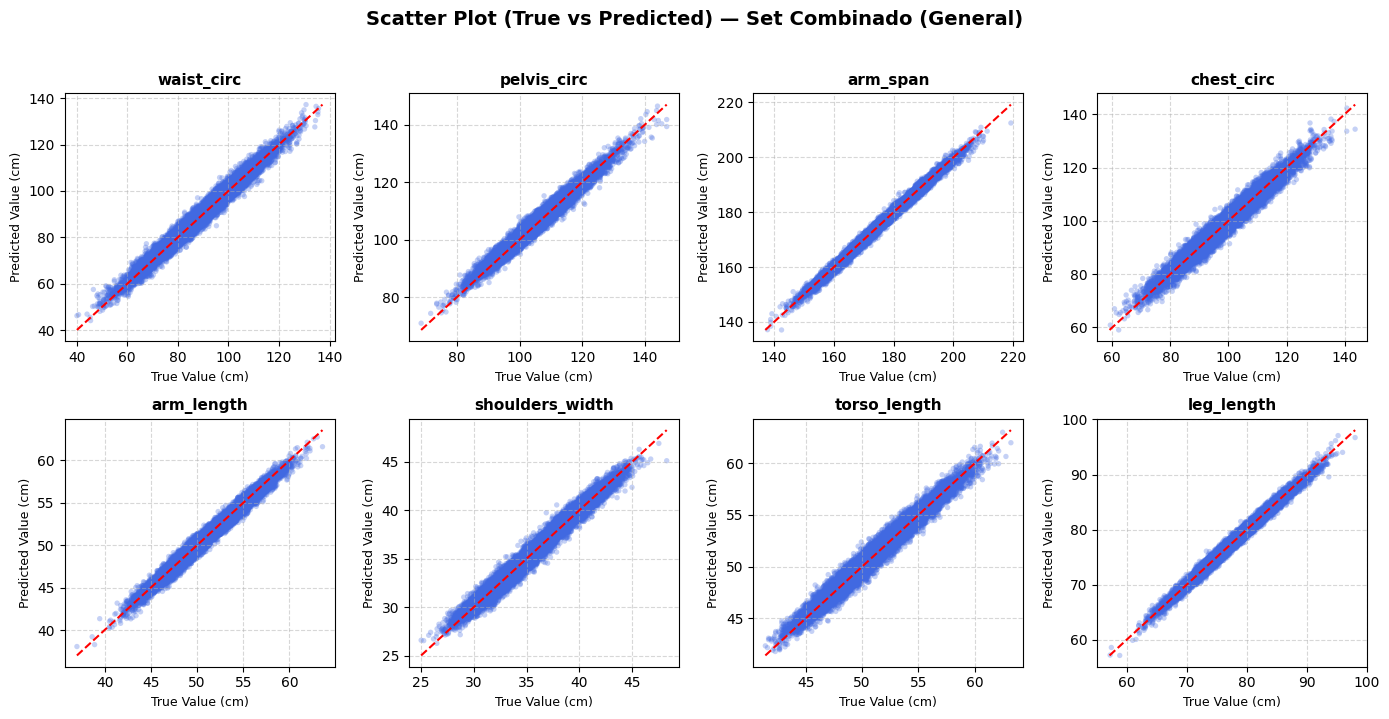

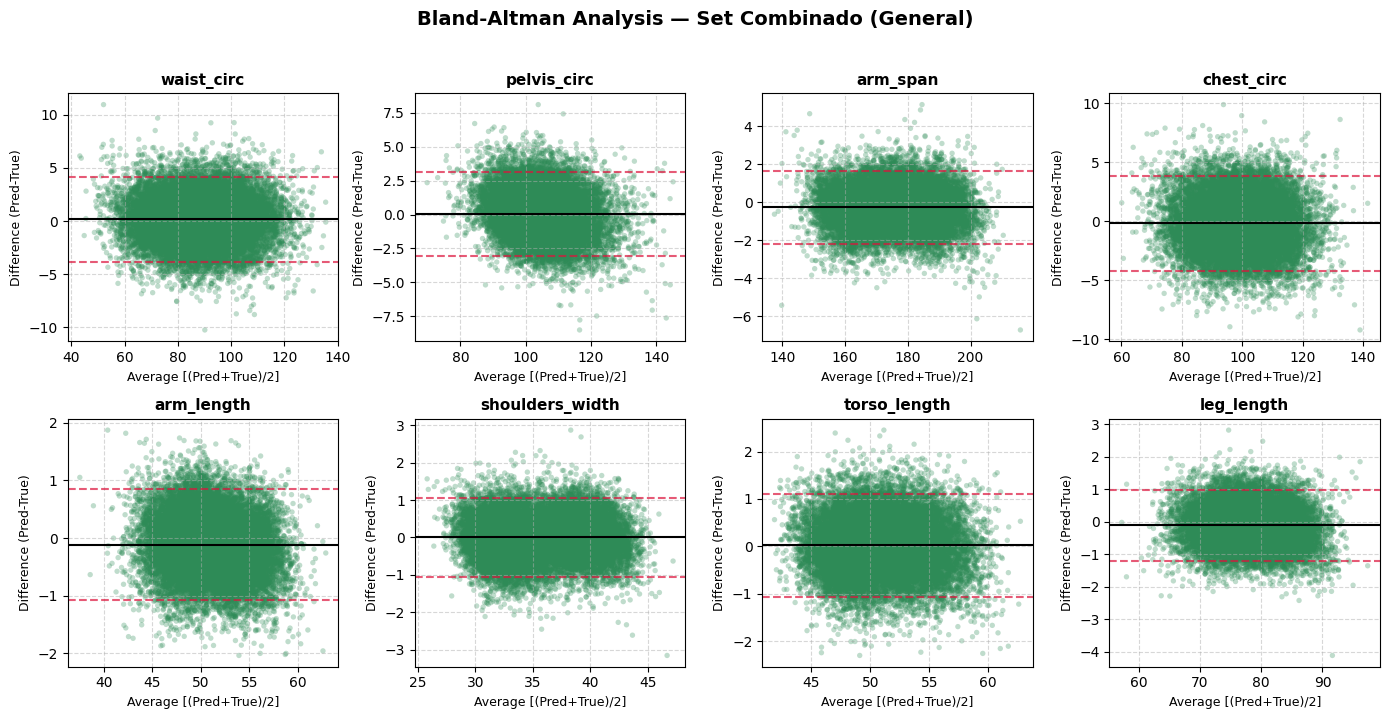

/tmp/ipykernel_1722/1954935158.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, patch_artist=True, labels=col_names,


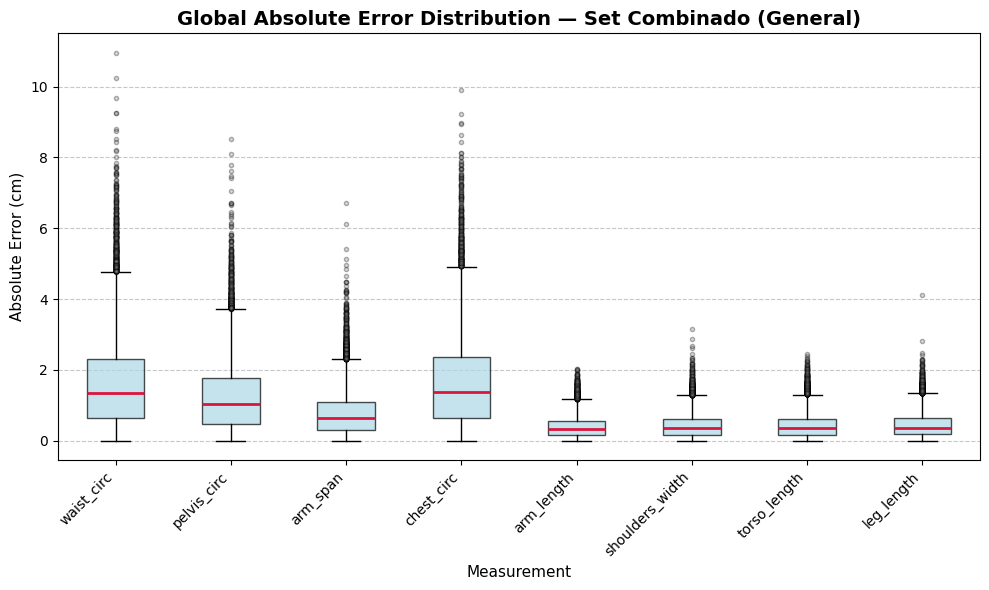

----------------------------------------



In [ ]:
print("\n" + "-" * 40)
print("Results for the MALE test set")
predict_measurements_and_evaluate(test_gen_male, model, mean, std, dataset_name="Men", plot_diagnostics=False)

print("\nResults for the FEMALE test set")
predict_measurements_and_evaluate(test_gen_female, model, mean, std, dataset_name="Women", plot_diagnostics=False)

print("\nResults for the COMBINED test set")
mean_mae = predict_measurements_and_evaluate(
    test_gen_total, model, mean, std,
    dataset_name="Set Combinado (General)",
    plot_diagnostics=True
)

print("-" * 40 + "\n")